<a href="https://colab.research.google.com/github/rubengamarro/practicas_aprendizaje_no_supervisado/blob/main/3_Redes_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EJERCICIO 1

In [715]:
import pandas as pd
import numpy as np

In [716]:
from sklearn.datasets import load_wine
data = load_wine()
X, y = data.data, data.target
X = pd.DataFrame(X, columns=data.feature_names)
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [717]:
for column in X.columns:
    print(f'{column}:\n Mínimo: {X[column].min()}, Máximo: {X[column].max()}')

alcohol:
 Mínimo: 11.03, Máximo: 14.83
malic_acid:
 Mínimo: 0.74, Máximo: 5.8
ash:
 Mínimo: 1.36, Máximo: 3.23
alcalinity_of_ash:
 Mínimo: 10.6, Máximo: 30.0
magnesium:
 Mínimo: 70.0, Máximo: 162.0
total_phenols:
 Mínimo: 0.98, Máximo: 3.88
flavanoids:
 Mínimo: 0.34, Máximo: 5.08
nonflavanoid_phenols:
 Mínimo: 0.13, Máximo: 0.66
proanthocyanins:
 Mínimo: 0.41, Máximo: 3.58
color_intensity:
 Mínimo: 1.28, Máximo: 13.0
hue:
 Mínimo: 0.48, Máximo: 1.71
od280/od315_of_diluted_wines:
 Mínimo: 1.27, Máximo: 4.0
proline:
 Mínimo: 278.0, Máximo: 1680.0


In [718]:
from sklearn.preprocessing import MinMaxScaler

#Normalizamos los datos
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [719]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [720]:
for column in X_scaled_df.columns:
    print(f'{column}:\n Mínimo: {X_scaled_df[column].min()}, Máximo: {X_scaled_df[column].max()}')

alcohol:
 Mínimo: 0.0, Máximo: 1.0
malic_acid:
 Mínimo: 0.0, Máximo: 1.0
ash:
 Mínimo: 0.0, Máximo: 0.9999999999999999
alcalinity_of_ash:
 Mínimo: 0.0, Máximo: 1.0
magnesium:
 Mínimo: 0.0, Máximo: 1.0
total_phenols:
 Mínimo: 0.0, Máximo: 1.0
flavanoids:
 Mínimo: 0.0, Máximo: 0.9999999999999998
nonflavanoid_phenols:
 Mínimo: 0.0, Máximo: 1.0
proanthocyanins:
 Mínimo: 0.0, Máximo: 0.9999999999999999
color_intensity:
 Mínimo: 0.0, Máximo: 0.9999999999999999
hue:
 Mínimo: 0.0, Máximo: 1.0
od280/od315_of_diluted_wines:
 Mínimo: 0.0, Máximo: 1.0
proline:
 Mínimo: 0.0, Máximo: 1.0


In [721]:
from sklearn.model_selection import train_test_split

#Dividimos los datos en entrenamiento y validación
X_ent, X_val, y_ent, y_val = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=10)

**Apartado b**

Introducimos las funciones y clases que necesitamos

In [722]:
import numpy as np

#Definición función logística simplificada,
#la general sería: 1. / (1. + np.exp(-2*Beta*h))
def logistica(h):
    g = 1. / (1. + np.exp(-h))
    return g

#Definición derivada de la función logística simplificada
#Ojo: Esta implementación recibe directamente el valor de la función a
#derivar g(h)
def derivada_logistica(g):
    g_prima = g * (1. - g)
    return g_prima

#Recibe un vector de enteros (salidas deseadas) y lo convierte en una matriz,
#una fila para cada salida deseada con un valor 1 en la posición de la salida deseada
def naturales_a_vectores(y, num_clases):
    matrizRes = np.zeros((y.shape[0], num_clases))

    #Iteramos por las salidas deseadas
    for i, val in enumerate(y):
        matrizRes[i, val] = 1
    return matrizRes

In [723]:
def generador_lotes(X, y, tam_lote):
    num_muestras = X.shape[0]
    # Vector con todos los indices del conjunto de muestras:
    indices = np.arange(num_muestras)
    # Ordenamos aleatoriamente los índices:
    np.random.shuffle(indices)
    # Creamos los índices que compondrán cada lote:
    for idx_muestra_inic_lote in range(0, num_muestras - tam_lote + 1, tam_lote):
        if idx_muestra_inic_lote + tam_lote > num_muestras:
            break  # Ignorar el último lote si es más pequeño que tam_lote
        indices_lote = \
          indices[idx_muestra_inic_lote:idx_muestra_inic_lote + tam_lote]
        # Devolvemos los rasgos y salidas deseadas del lote:
        yield X[indices_lote], y[indices_lote]
        #OjO: yield es parecido a return, pero no devuelve todos los valores,
        #sirve para crear un generador de objetos, conforme se van necesitando
        #más objetos, se van generando, por lo que no es necesario generarlos
        #todos si sólo usaremos algunos de ellos

In [724]:
class PrototipoRedMulticapa:
    # Constructor:
    def __init__(self, num_rasgos, num_ocultas,
                 num_clases, semilla=10):
        super().__init__()
        rng = np.random.RandomState(semilla)

        self.num_salidas = num_clases

        #################
        ## Capa oculta ##
        #################
        self.W1 = rng.normal(
            loc=0.0, scale=0.1, size=(num_ocultas, num_rasgos))
        self.sesgos1 = np.zeros(num_ocultas)

        #################
        ## Capa salida ##
        #################
        self.W2 = rng.normal(
            loc=0.0, scale=0.1, size=(self.num_salidas, num_ocultas))
        self.sesgos2 = np.zeros(self.num_salidas)

    # Calcula la salida de la red ante unos estímulos (lotes):
    def forward(self, X):
        # Dimensiones variables:
        # X -> [num_muestras x num_rasgos]

        #################
        ## Capa oculta ##
        #################

        # [num_muestras, num_ocultas] = [num_muestras x num_rasgos] · [num_ocultas, num_rasgos].T + [num_ocultas] "Se suman los sesgos en cada fila"
        pot_oculta = np.dot(X, self.W1.T) + self.sesgos1

        # [num_muestras, num_ocultas] = [num_muestras, num_ocultas]
        S = logistica(pot_oculta)

        #################
        ## Capa salida ##
        #################

        # [num_muestras, num_salidas] = [num_muestras, num_ocultas] · [num_salidas, num_ocultas].T + [num_salidas] "Se suman los sesgos en cada fila"
        pot_salida = np.dot(S, self.W2.T) + self.sesgos2

        # [num_muestras, num_salidas] = [num_muestras, num_salidas]
        y_predichas = logistica(pot_salida)

        return S, y_predichas

    # Calcula diferenciales de pesos sinápticos y sesgos
    # retropropagando el error (lotes):
    def backward(self, X, S, Y_pred, y_deseada):
        # Dimensiones variables:
        # X -> [num_muestras x num_rasgos] -> Rasgos
        # S -> [num_muestras x num_ocultas] -> Estados capa oculta
        # Y_pred -> [num_muestras x num_salidas] -> Matriz con salidas predichas
        # y_deseada -> [num_muestras x 1] -> Vector con salidas deseadas

        # [num_muestras x num_salidas] = [num_muestras x 1]
        Y_des = naturales_a_vectores(y_deseada, self.num_salidas)

        #################
        ## Capa salida ##
        #################

        # Valor escalar, "p" en los apuntes
        num_muestras = y_deseada.shape[0]

        # OJO: No es lo mismo el producto de matrices elemento a elemento "*"
        # que el producto escalar "np.dot(...)"

        # [num_muestras x num_salidas] = [num_muestras x num_salidas] * [num_muestras x num_salidas]
        delta_2 = (Y_des - Y_pred) / num_muestras * derivada_logistica(Y_pred)

        # [num_salidas x num_ocultas] = [num_muestras x num_salidas].T · [num_muestras x num_ocultas]
        dif_W2 = np.dot(delta_2.T, S)

        # [num_salidas] = [num_muestras x num_salidas]
        dif_sesgos2 = np.sum(delta_2, axis=0)

        #################
        ## Capa oculta ##
        #################

        # [num_muestras x num_ocultas] = [num_muestras x num_ocultas] * ([num_muestras x num_salidas] · [num_salidas x num_ocultas])
        delta_1 = derivada_logistica(S) * np.dot(delta_2, self.W2)

        # [num_ocultas x num_rasgos] = [num_muestras x num_ocultas].T · [num_muestras x num_rasgos]
        dif_W1 = np.dot(delta_1.T, X)

        # [num_ocultas] = [num_muestras x num_ocultas]
        dif_sesgos1 = np.sum(delta_1, axis=0)

        return (dif_W2, dif_sesgos2,
                dif_W1, dif_sesgos1)

In [725]:
# Calcula ECM de un lote
def calcula_ECM(y_deseadas, prob_salidas):
    #Formato de entrada: [num_muestras x num_clases]
    return np.mean((y_deseadas - prob_salidas)**2)

# Calcula exactitud de un lote
def calcula_exactitud(clases_deseadas, clases_pred):
    #Formato de entrada: [num_muestras]
    return np.mean(clases_deseadas == clases_pred)

In [726]:
# Calcula ECM y exactitud de un conjunto de muestras para una red neuronal
# Divide los cálculos lote a lote para evitar problemas de memoria
def calcular_ecm_exactitud(redNeuronal, X, y, num_clases, tam_lote=100):
    ecm_total, exact_total, num_lotes = 0., 0., 0

    gen_lotes = generador_lotes(X, y, tam_lote)
    for (X_lote, y_deseadas_lote) in gen_lotes:
        # [tam_lote x num_clases] = ...
        _, Prob_salidas = redNeuronal.forward(X_lote)

        # Para cada muestra, obtenemos la posición de la componente de mayor probabilidad
        # [tam_lote] = ...
        clases_pred = np.argmax(Prob_salidas, axis=1)
        exact_total += calcula_exactitud(y_deseadas_lote, clases_pred)

        # Construimos una matriz donde cada fila es un vector de componentes deseadas
        # [tam_lote x num_clases] = ...
        Clases_des = naturales_a_vectores(y_deseadas_lote, num_clases)
        ecm_total += calcula_ECM(Clases_des, Prob_salidas)

        num_lotes += 1

    ecm_total = ecm_total/num_lotes
    exact_total = exact_total/num_lotes

    return ecm_total, exact_total

In [727]:
class RedMulticapa(PrototipoRedMulticapa):

    def entrenar(self, X_ent, y_ent, X_val, y_val, num_epocas=10,
                 tasa_aprend=0.1, tam_lote=100):
        ecm_ent_epocas, exact_ent_epocas, exact_val_epocas = [], [], []

        # Iteramos sobre las épocas
        for idx_epoca in range(num_epocas):
            # Iteramos sobre los lotes
            gen_lotes = generador_lotes(X_ent, y_ent, tam_lote)
            for X_ent_lote, y_ent_lote in gen_lotes:
                #### Calcular salidas ####
                S, y_pred = self.forward(X_ent_lote)

                #### Calcular diferenciales de pesos y sesgos ####
                dif_W2, dif_sesgos2, dif_W1, dif_sesgos1 = \
                    self.backward(X_ent_lote, S, y_pred, y_ent_lote)

                #### Actualización de pesos ####
                self.W1 += tasa_aprend * dif_W1
                self.sesgos1 += tasa_aprend * dif_sesgos1
                self.W2 += tasa_aprend * dif_W2
                self.sesgos2 += tasa_aprend * dif_sesgos2

            #### Anotamos rendimientos al finalizar época ####
            ecm_ent, exact_ent = calcular_ecm_exactitud(
                self, X_ent, y_ent, self.num_salidas, tam_lote)
            ecm_val, exact_val = calcular_ecm_exactitud(
                self, X_val, y_val, self.num_salidas, tam_lote)

            exact_ent = exact_ent*100
            exact_val = exact_val*100
            exact_ent_epocas.append(exact_ent)
            exact_val_epocas.append(exact_val)
            ecm_ent_epocas.append(ecm_ent)
            print(f'Época: {idx_epoca+1:03d}/{num_epocas:03d} '
                  f'| ECM entrenamiento: {ecm_ent:.2f} '
                  f'| Exact entrenamiento: {exact_ent:.2f}% '
                  f'| Exact Validación: {exact_val:.2f}%')

        return ecm_ent_epocas, exact_ent_epocas, exact_val_epocas

Creamos la red multicapa

In [728]:
redMLP = RedMulticapa(num_rasgos=13,
                      num_ocultas=40,
                      num_clases=3)

Entrenamos el modelo

In [729]:
np.random.seed(10)
ecm_ent_epocas, exact_ent_epocas, exact_val_epocas = redMLP.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=30, tasa_aprend=0.3, tam_lote=5)

Época: 001/030 | ECM entrenamiento: 0.22 | Exact entrenamiento: 40.00% | Exact Validación: 40.00%
Época: 002/030 | ECM entrenamiento: 0.22 | Exact entrenamiento: 40.71% | Exact Validación: 40.00%
Época: 003/030 | ECM entrenamiento: 0.22 | Exact entrenamiento: 40.00% | Exact Validación: 37.14%
Época: 004/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.71% | Exact Validación: 40.00%
Época: 005/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 68.57% | Exact Validación: 68.57%
Época: 006/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.00% | Exact Validación: 40.00%
Época: 007/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.71% | Exact Validación: 37.14%
Época: 008/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.71% | Exact Validación: 37.14%
Época: 009/030 | ECM entrenamiento: 0.21 | Exact entrenamiento: 40.00% | Exact Validación: 40.00%
Época: 010/030 | ECM entrenamiento: 0.20 | Exact entrenamiento: 40.71% | Exact Validación: 40.00%
Época: 011/030 | ECM

**Apartado c**

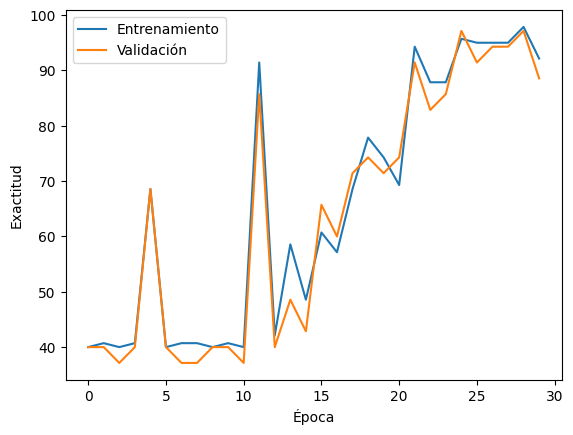

In [730]:
from matplotlib import pyplot as plt

plt.plot(range(len(exact_ent_epocas)), exact_ent_epocas,
         label='Entrenamiento')
plt.plot(range(len(exact_val_epocas)), exact_val_epocas,
         label='Validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='best')
plt.show()

Podemos ver como hasta la época 10-15 el modelo está subajustado pero a partir de ahí el modelo clasifica bien. A partir de las 25-30 épocas vemos como el modelo llega a un máximo de exactitud y empieza a estabilizarse e incluso a decaer, lo que puede significar un poco de sobreajuste a partir de 30 épocas.

**Apartado d**

In [731]:
_, prob_salidas = redMLP.forward(X_val)
val_pred = np.argmax(prob_salidas, axis=1)

In [732]:
print("\nMuestras mal clasificadas:")
for i in range(len(y_val)):
    if val_pred[i] != y_val[i]:
        print(f"\nMuestra: {i}")
        print(f"Clase deseada: {y_val[i]}")
        print(f"Clase predicha: {val_pred[i]}")
        print(f"Probabilidades: {prob_salidas[i]}")


Muestras mal clasificadas:

Muestra: 10
Clase deseada: 1
Clase predicha: 2
Probabilidades: [0.18705643 0.37091645 0.43676557]

Muestra: 13
Clase deseada: 1
Clase predicha: 0
Probabilidades: [0.611096   0.44781507 0.07745454]

Muestra: 23
Clase deseada: 1
Clase predicha: 0
Probabilidades: [0.52109651 0.44570163 0.10835312]

Muestra: 27
Clase deseada: 1
Clase predicha: 0
Probabilidades: [0.57002829 0.47241237 0.08450357]


#EJERCICIO 2

In [733]:
from sklearn.datasets import fetch_olivetti_faces
data = fetch_olivetti_faces()
X, y = data.data, data.target
X = pd.DataFrame(X, columns=[f'Pixel {i+1}' for i in range(X.shape[1])])
X

,Pixel 1,Pixel 2,Pixel 3,Pixel 4,Pixel 5,Pixel 6,Pixel 7,Pixel 8,Pixel 9,Pixel 10,...,Pixel 4087,Pixel 4088,Pixel 4089,Pixel 4090,Pixel 4091,Pixel 4092,Pixel 4093,Pixel 4094,Pixel 4095,Pixel 4096
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.388430,0.396694,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364
396,0.367769,0.367769,0.351240,0.301653,0.247934,0.247934,0.367769,0.512397,0.574380,0.628099,...,0.380165,0.334711,0.289256,0.285124,0.338843,0.404959,0.458678,0.487603,0.512397,0.549587
397,0.500000,0.533058,0.607438,0.628099,0.657025,0.632231,0.657025,0.669421,0.673554,0.702479,...,0.194215,0.148760,0.152893,0.161157,0.161157,0.173554,0.157025,0.177686,0.148760,0.190083
398,0.214876,0.219008,0.219008,0.223140,0.210744,0.202479,0.276859,0.400826,0.487603,0.549587,...,0.446281,0.392562,0.367769,0.409091,0.479339,0.524793,0.545455,0.574380,0.590909,0.603306


In [734]:
altoDigito, anchoDigito = 64, 64

**Apartado a**

In [735]:
from sklearn.preprocessing import MinMaxScaler

#Normalizamos los datos
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [736]:
from sklearn.model_selection import train_test_split

#Dividimos los datos en entrenamiento y validación
X_ent, X_val, y_ent, y_val = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=10)

**Apartado b**

In [737]:
redMLP2 = RedMulticapa(num_rasgos=altoDigito*anchoDigito,
                      num_ocultas=80,
                      num_clases=40)

In [738]:
np.random.seed(10)
ecm_ent_epocas, exact_ent_epocas, exact_val_epocas = redMLP2.entrenar(
    X_ent, y_ent, X_val, y_val, num_epocas=100, tasa_aprend=0.3, tam_lote=5)

Época: 001/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 2.50% | Exact Validación: 3.75%
Época: 002/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 5.31% | Exact Validación: 7.50%
Época: 003/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 8.44% | Exact Validación: 6.25%
Época: 004/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 9.06% | Exact Validación: 10.00%
Época: 005/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 10.63% | Exact Validación: 5.00%
Época: 006/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 10.63% | Exact Validación: 10.00%
Época: 007/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 15.63% | Exact Validación: 16.25%
Época: 008/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 11.25% | Exact Validación: 8.75%
Época: 009/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 10.94% | Exact Validación: 11.25%
Época: 010/100 | ECM entrenamiento: 0.02 | Exact entrenamiento: 10.63% | Exact Validación: 10.00%
Época: 011/100 | ECM entrenam

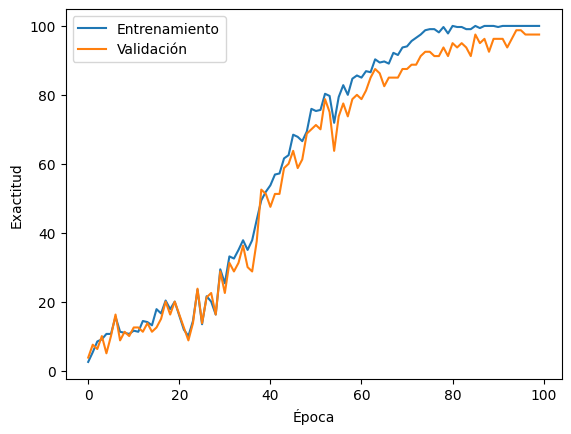

In [739]:
from matplotlib import pyplot as plt

plt.plot(range(len(exact_ent_epocas)), exact_ent_epocas,
         label='Entrenamiento')
plt.plot(range(len(exact_val_epocas)), exact_val_epocas,
         label='Validación')
plt.ylabel('Exactitud')
plt.xlabel('Época')
plt.legend(loc='best')
plt.show()

**Apartado c**